# Predictive Modeling

Hotel Booking Cancellation Prediction


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv(r"C:\Users\DELL\Documents\GitHub\INFOTACT-Internship-Team-5\Week2\processed_data.csv")
df.head()

,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,customertype,adr,requiredcarparkingspaces,totalofspecialrequests,reservationstatus,reservationstatusdate,total_guests,total_stay,revenue,arrival_month_number
0,0,342,2015,July,27,1,0,0,2,0,...,Transient,0.0,0,0,Check-Out,2015-07-01,2,0,0.0,7
1,0,737,2015,July,27,1,0,0,2,0,...,Transient,0.0,0,0,Check-Out,2015-07-01,2,0,0.0,7
2,0,7,2015,July,27,1,0,1,1,0,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,75.0,7
3,0,13,2015,July,27,1,0,1,1,0,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,75.0,7
4,0,14,2015,July,27,1,0,2,2,0,...,Transient,98.0,0,1,Check-Out,2015-07-03,2,2,196.0,7


In [4]:
y = df['iscanceled']
X = df.drop(['iscanceled'], axis=1)

X = pd.get_dummies(X, drop_first=True)

In [5]:
X.shape

(33956, 1107)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5248
           1       1.00      1.00      1.00      1544

    accuracy                           1.00      6792
   macro avg       1.00      1.00      1.00      6792
weighted avg       1.00      1.00      1.00      6792



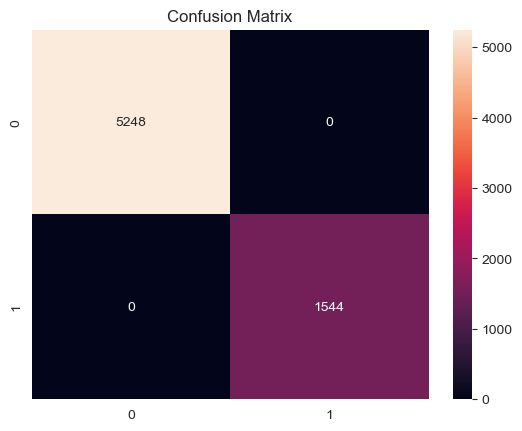

In [10]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

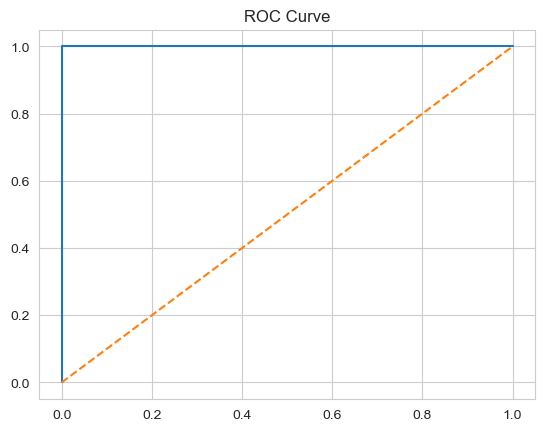

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()

In [12]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

feature_importance.head(10)

,Feature,Coefficient
194,reservationstatus_No-Show,0.535440
1,arrivaldateyear,0.300966
130,country_PRT,0.280751
0,leadtime,0.261470
10,previouscancellations,0.239343
14,adr,0.217924
165,marketsegment_Online TA,0.156801
188,deposittype_Non Refund,0.153809
290,reservationstatusdate_2015-06-17,0.138721
300,reservationstatusdate_2015-06-29,0.121633


In [13]:
feature_importance.tail(10)

,Feature,Coefficient
90,country_IRL,-0.093146
23,arrivaldatemonth_February,-0.096200
182,assignedroomtype_F,-0.106189
9,isrepeatedguest,-0.116263
180,assignedroomtype_D,-0.161490
164,marketsegment_Offline TA/TO,-0.161945
80,country_GBR,-0.164804
16,totalofspecialrequests,-0.169425
15,requiredcarparkingspaces,-0.388530
193,reservationstatus_Check-Out,-6.406978


## Train Decision Tree

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve)

In [15]:
dt_model = DecisionTreeClassifier(
    max_depth=5,         # control overfitting
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

In [16]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [17]:
y_pred_dt

array([0, 0, 0, ..., 0, 1, 0])

In [18]:
y_prob_dt

array([0., 0., 0., ..., 0., 1., 0.])

## Evaluation Metrics

In [19]:
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
roc_auc = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("ROC-AUC:", roc_auc)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
ROC-AUC: 1.0

Confusion Matrix:
 [[5248    0]
 [   0 1544]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5248
           1       1.00      1.00      1.00      1544

    accuracy                           1.00      6792
   macro avg       1.00      1.00      1.00      6792
weighted avg       1.00      1.00      1.00      6792



## ROC Curve

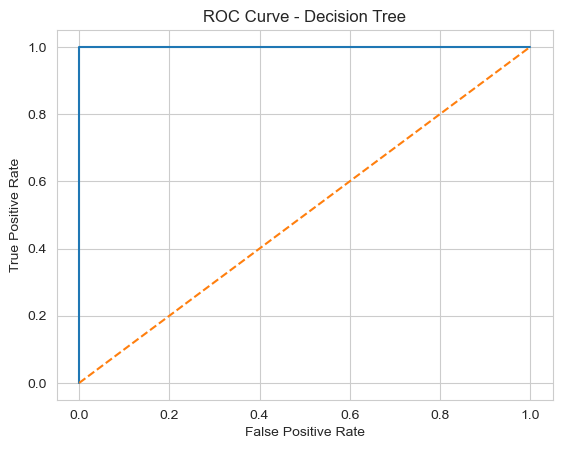

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.show()